# <span style="color:#00bfff">Unidad 3. Implementación de modelos de Machine learning</span>

## <span style="color:#00bfff">Aprendizaje Supervisado</span>

### <spam style="color:#00bfff">Regresión en Aprendizaje Supervisado </span>

**Regresión Lineal Simple** 

Ejemplo: Suponiendo los siguientes datos: 

|Tamaño (m²) | Precio (USD)|
|:----------:|:-----------:|
| 50 | 100 |
| 80 | 150 |
| 120 | 200 |

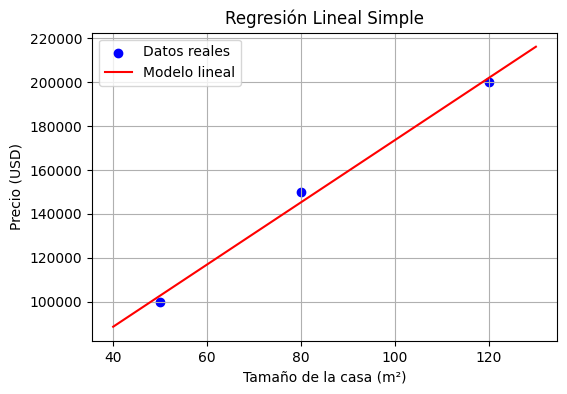

Intercepto (β₀): 31756.75675675676
Pendiente (β₁): 1418.918918918919


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Datos de ejemplo
X = np.array([[50], [80], [120]])  # Tamaño de la casa (m²)
y = np.array([100000, 150000, 200000])  # Precio

# Crear y ajustar el modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Predicciones
X_pred = np.linspace(40, 130, 100).reshape(-1, 1)
y_pred = modelo.predict(X_pred)

# Visualización
plt.figure(figsize=(6,4))
plt.scatter(X, y, color='blue', label='Datos reales')
plt.plot(X_pred, y_pred, color='red', label='Modelo lineal')
plt.xlabel('Tamaño de la casa (m²)')
plt.ylabel('Precio (USD)')
plt.title('Regresión Lineal Simple')
plt.legend()
plt.grid()
plt.show()

# Coeficientes
print(f"Intercepto (β₀): {modelo.intercept_}")
print(f"Pendiente (β₁): {modelo.coef_[0]}")

### Evaluación de modelos de predicción

In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Datos reales y predicciones
y_real = y
y_pred_real = modelo.predict(X)

# Cálculo de métricas
mae = mean_absolute_error(y_real, y_pred_real)
mse = mean_squared_error(y_real, y_pred_real)
rmse = np.sqrt(mse)
r2 = r2_score(y_real, y_pred_real)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MAE: 3153.15
MSE: 11261261.26
RMSE: 3355.78
R²: 0.9932


### Ejemplo Regresión: Dataset California Housing

El dataset California Housing fue creado a partir del censo de 1990 en California (EE. UU.). Su objetivo es predecir el valor medio de las viviendas en distintos bloques geográficos, a partir de datos socioeconómicos y demográficos. 

Variable objetivo (y): ```MedHouseVal```: valor medio de la vivienda (en centenas de miles de dólares) 

| Variable | Descripción |
|:---:|:---:|
|`MedInc`| Ingreso medio de los hogares en el bloque |
| `HouseAge` | Edad media en las viviendas del bloque |
| `AveRooms`| Promedio de habitaciones por vivienda |
| `AveBedrms`| Promedio de dormitorios por vivienda |
| `Population`| Población total del bloque |
|  `AveOccup`| Promedio de personas por vivienda |
| `Latitude` | Latitud geográfica del bloque |
| `Longitude` | Longitud geográfica del bloque |

1. Importación de librearías

In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

2. Preparación del dataset

In [4]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # Mediana del valor de la vivienda (en cientos de miles)

X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")

Dimensiones de X_train: (16512, 8)
Dimensiones de y_train: (16512,)


3. Creación y entrenamiento del modelo de Regresión Lineal

In [6]:
modelo = LinearRegression()
modelo.fit(X_train, y_train) 

LinearRegression()

4. Predicción del conjunto de prueba

In [7]:
y_pred = modelo.predict(X_test)
y_pred

array([0.71912284, 1.76401657, 2.70965883, ..., 4.46877017, 1.18751119,
       2.00940251])

5. Evaluación del modelo

In [8]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Evaluación del Modelo:")
print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.4f}")

Evaluación del Modelo:
MAE: 0.533
MSE: 0.556
RMSE: 0.746
R²: 0.5758


6. Visualización de valores predichos vs. valore reales

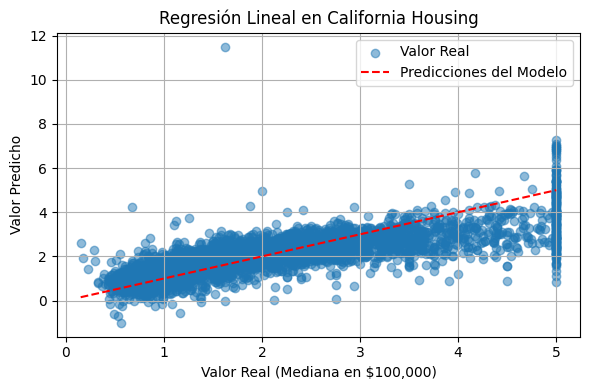

In [9]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Valor Real (Mediana en $100,000)")
plt.ylabel("Valor Predicho")
plt.title("Regresión Lineal en California Housing")
plt.grid(True)
plt.legend(["Valor Real", "Predicciones del Modelo"])
plt.tight_layout()
plt.show()

### <spam style="color:#00bfff">Clasificación en Aprendizaje Supervisado </span>

#### k-Nearest Neighbors k-NN

k-NN (k-Nearest Neighbors) es un algoritmo de clasificación basado en la proximidad. Para clasificar un nuevo ejemplo, el modelo: 

1. Busca los k vecinos más cercanos en el conjunto de entrenamiento.
2. Toma una votación (clasificación) o promedio (regresión) según las clases de esos vecinos.
3. Ideal para problemas donde la geometría del espacio es relevante.

Para clasificar un punto nuevo $(x,y)$, busca sus k vecinos más cercanos según una métrica (por defecto, distancia Euclidiana): 

$\text{dist}(x, x_i) = \sqrt{\sum_{j=1}^n (x_j - x_{ij})^2}$

Implementación del algoritmo k-NN en el **dataset Iris** aprovechando su característica multiclase:

In [10]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Cargar datos
iris = load_iris()
X, y = iris.data, iris.target

# 2. Escalar datos (importante para k-NN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 4. Entrenar modelo k-NN
modelo_knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights='uniform')
modelo_knn.fit(X_train, y_train)

# 5. Predicciones y evaluación
y_pred = modelo_knn.predict(X_test)
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))

Matriz de Confusión:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Ejemplo de clasificación y visualización de k-NN

Matriz de Confusión:
 [[12  2  6]
 [ 3 15  1]
 [ 0  0 21]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.80      0.60      0.69        20
           1       0.88      0.79      0.83        19
           2       0.75      1.00      0.86        21

    accuracy                           0.80        60
   macro avg       0.81      0.80      0.79        60
weighted avg       0.81      0.80      0.79        60



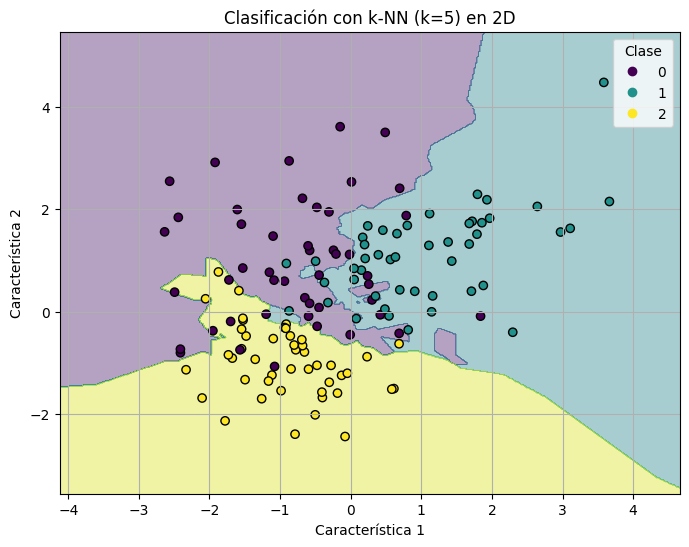

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# 1. Crear un conjunto de datos 2D
X, y = make_classification(
    n_samples=200,  # Número de muestras
    n_features=2,  # Solo dos características
    n_redundant=0,
    n_clusters_per_class=1,
    n_classes=3,
    random_state=42,
)

# 2. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Entrenar el modelo k-NN
modelo = KNeighborsClassifier(n_neighbors=5)
modelo.fit(X_train, y_train)

# 4. Visualización de regiones de decisión
y_pred = modelo.predict(X_test) 
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))

# Crear una malla de puntos (rejilla) para cubrir el espacio de características
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predecir la clase para cada punto de la malla
Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Dibujar la región de decisión
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap="viridis")

# Dibujar los puntos de entrenamiento
scatter = plt.scatter(
    X_train[:, 0], X_train[:, 1], c=y_train, edgecolor="k", cmap="viridis"
)
plt.title("Clasificación con k-NN (k=5) en 2D")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.legend(*scatter.legend_elements(), title="Clase")
plt.grid(True)
plt.show()

#### Árboles de Decisión (Decision Trees)

Ejemplo de clasificación con Árboles de Decisión y el conjunto de datos Iris

Matriz de confusión:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



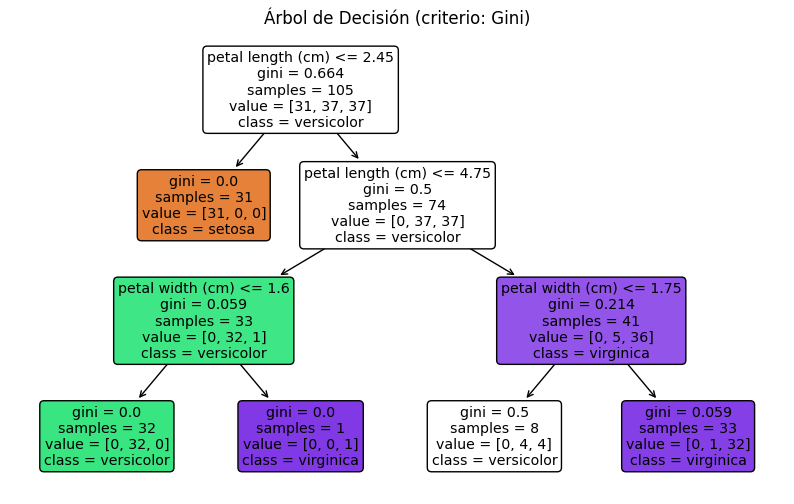

In [12]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# 1. Cargar datos
iris = load_iris()
X, y = iris.data, iris.target

# 2. Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Crear y entrenar modelo de Árbol de Decisión
modelo = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
modelo.fit(X_train, y_train)

# 4. Evaluar modelo
y_pred = modelo.predict(X_test)
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

# 5. Visualizar el árbol
plt.figure(figsize=(10, 6))
plot_tree(
    modelo,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
)
plt.title("Árbol de Decisión (criterio: Gini)")
plt.show()

## <span style="color:#00bfff">Aprendizaje No Supervisado</span>

### <span style="color:#00bfff">Clustering</span>

El clustering es una técnica que busca agrupar instancias similares en conjuntos llamados clusters, sin usar etiquetas previas.

📌 Objetivo:
Descubrir estructura o patrones ocultos en los datos, asignando a cada observación un grupo basado en su proximidad o similitud.

#### <span style="color:#00bfff">Clustering con K-Means</span>

K-Means es un algoritmo de agrupamiento que busca dividir los datos en k grupos o clústeres, de modo que los puntos dentro de cada clúster sean lo más similares posible entre sí y diferentes a los de otros clústeres.

c:\Users\sebas\OneDrive\Documentos\GitHub\IA-Course-UdB\Unidad 3\u3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\sebas\OneDrive\Documentos\GitHub\IA-Course-UdB\Unidad 3\u3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\sebas\AppData\Roaming\uv\python\cpython-3.11.14-windows-x86_64-none\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sebas\AppData\Roaming\uv\python\cpython-3.11.14-windows-x86_64-none\Lib\subprocess.py", line 102

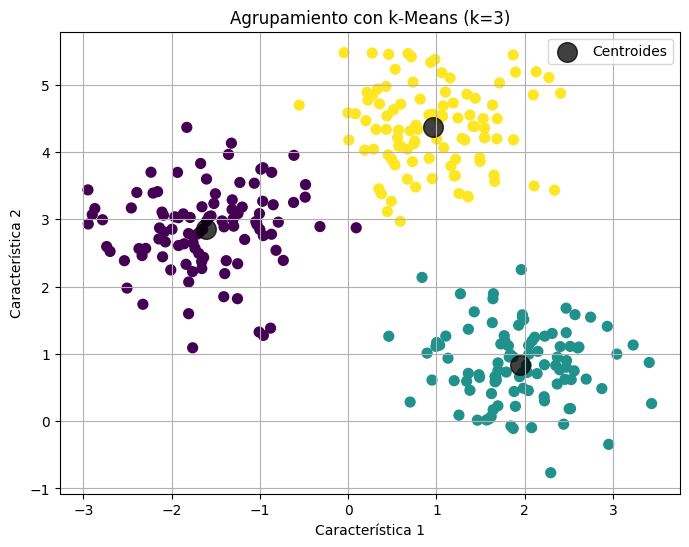

Puntaje Silhouette: 0.660


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Generar un conjunto de datos 2D simulado con 3 centros
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=0)

# 2. Crear y ajustar el modelo k-Means
k = 3
modelo = KMeans(n_clusters=k, random_state=0)
y_kmeans = modelo.fit_predict(X)

# 3. Visualizar los clusters encontrados
plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
plt.scatter(modelo.cluster_centers_[:, 0], modelo.cluster_centers_[:, 1], c='black', s=200, alpha=0.75, label='Centroides')
plt.title("Agrupamiento con k-Means (k=3)")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.legend()
plt.grid(True)
plt.show()

# 4. Evaluar la calidad del clustering con Silhouette Score
sil_score = silhouette_score(X, y_kmeans)
print(f"Puntaje Silhouette: {sil_score:.3f}")

## <span style="color:#00bfff">Modelos Avanzados de Machine Learning</span>

### <span style="color:#00bfff">Modelos de Ensamble</span>

Un modelo de ensamble combina múltiples modelos base (por lo general, débiles o moderados) para formar un modelo más robusto y preciso.

#### <span style="color:#00bfff">Random Forest</span>

Ejemplo  completo de clasificación con **Random Forest** usando el dataset de Iris. Incluye entrenamiento, evaluación y análisis de la importancia de características.

In [14]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd

# 1. Cargar datos
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# 2. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Crear y entrenar modelo Random Forest
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# 4. Predicción y evaluación
y_pred = modelo.predict(X_test)

print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred, target_names=iris.target_names))


Matriz de Confusión:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Reporte de Clasificación:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



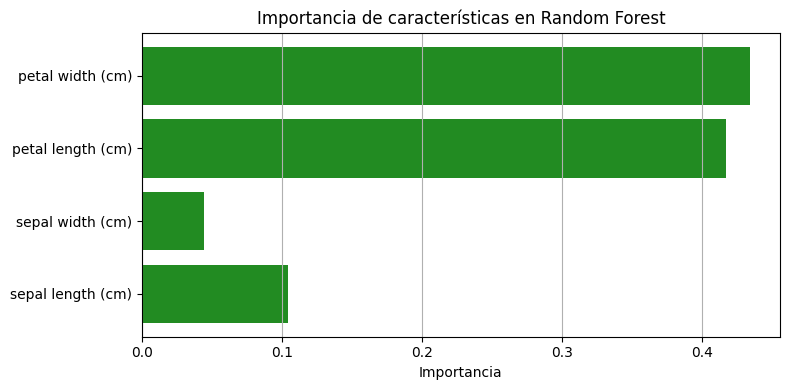

In [15]:
# 5. Importancia de características
importancias = modelo.feature_importances_
features = X.columns

# Visualizar
plt.figure(figsize=(8, 4))
plt.barh(features, importancias, color='forestgreen')
plt.xlabel("Importancia")
plt.title("Importancia de características en Random Forest")
plt.grid(axis='x')
plt.tight_layout()
plt.show() 

#### <span style="color:#00bfff">XGBoost</span>

Ejemplo de XGBoost usando el dataset Iris, incluyendo entrenamiento, evaluación y análisis de la importancia de las características. 

In [16]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


c:\Users\sebas\OneDrive\Documentos\GitHub\IA-Course-UdB\Unidad 3\u3\Scripts\python.exe: No module named pip


In [17]:
import xgboost as xgb
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd

# 1. Cargar datos
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# 2. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Crear y entrenar modelo XGBoost
modelo = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric="mlogloss",
)

modelo.fit(X_train, y_train)

# 4. Evaluar el modelo
y_pred = modelo.predict(X_test)
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print(
    "\nReporte de Clasificación:\n",
    classification_report(y_test, y_pred, target_names=iris.target_names),
)

Matriz de Confusión:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Reporte de Clasificación:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



c:\Users\sebas\OneDrive\Documentos\GitHub\IA-Course-UdB\Unidad 3\u3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:55:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Visualización de importancia de características

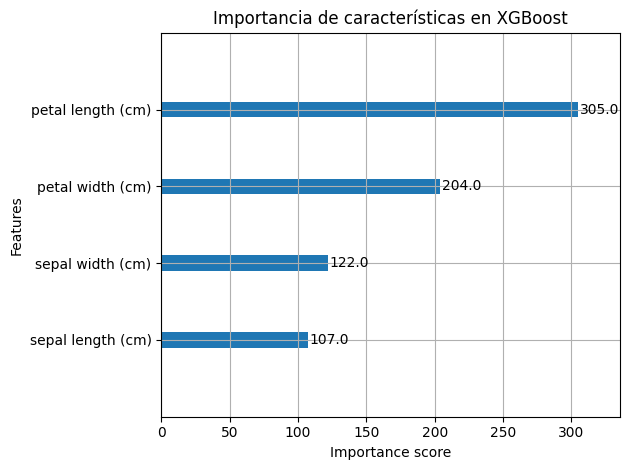

In [18]:
# 5. Importancia de variables
xgb.plot_importance(modelo)
plt.title("Importancia de características en XGBoost")
plt.tight_layout()
plt.show()

### <span style="color:#00bfff">AutoML</span>

#### <span style="color:#00bfff">PyCaret</span>

1. Instalación en el entorno. Preferiblemente un entorno virtual limpio.

In [19]:
%pip install pycaret

Note: you may need to restart the kernel to use updated packages.


c:\Users\sebas\OneDrive\Documentos\GitHub\IA-Course-UdB\Unidad 3\u3\Scripts\python.exe: No module named pip


In [20]:
from pycaret.datasets import get_data
from pycaret.classification import *

# 1. Cargar el dataset Iris
iris = get_data('iris')

# 2. Configurar el entorno de PyCaret (setup)
# Se define 'species' como la variable objetivo
exp = setup(data=iris, target='species', session_id=42, verbose=False)

# 3. Comparar automáticamente múltiples modelos
best_model = compare_models()

# 4. Evaluar el mejor modelo
evaluate_model(best_model)

# 5. Predecir sobre nuevos datos
predictions = predict_model(best_model)
print(predictions.head()) 

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
qda,Quadratic Discriminant Analysis,0.9809,0.0000,0.9809,0.9852,0.9805,0.9711,0.9735,0.0060
nb,Naive Bayes,0.9727,0.9974,0.9727,0.9806,0.9714,0.9588,0.9638,0.0060
lda,Linear Discriminant Analysis,0.9718,0.0000,0.9718,0.9780,0.9712,0.9573,0.9609,0.0050
et,Extra Trees Classifier,0.9718,1.0000,0.9718,0.9780,0.9712,0.9573,0.9609,0.0240
lr,Logistic Regression,0.9618,0.0000,0.9618,0.9705,0.9610,0.9422,0.9470,0.3590
ada,Ada Boost Classifier,0.9618,0.0000,0.9618,0.9705,0.9610,0.9422,0.9470,0.0130
knn,K Neighbors Classifier,0.9527,0.9888,0.9527,0.9595,0.9520,0.9284,0.9322,0.1970
rf,Random Forest Classifier,0.9518,0.9951,0.9518,0.9660,0.9487,0.9270,0.9352,0.0300
gbc,Gradient Boosting Classifier,0.9518,0.0000,0.9518,0.9660,0.9487,0.9270,0.9352,0.0320
xgboost,Extreme Gradient Boosting,0.9436,0.9847,0.9436,0.9588,0.9417,0.9149,0.9236,0.0120


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Quadratic Discriminant Analysis,0.9778,1.0000,0.9778,0.9792,0.9778,0.9667,0.9674


     sepal_length  sepal_width  petal_length  petal_width          species  \
107           7.3          2.9           6.3          1.8   Iris-virginica   
63            6.1          2.9           4.7          1.4  Iris-versicolor   
133           6.3          2.8           5.1          1.5   Iris-virginica   
56            6.3          3.3           4.7          1.6  Iris-versicolor   
127           6.1          3.0           4.9          1.8   Iris-virginica   

    prediction_label  prediction_score  
107   Iris-virginica            0.9998  
63   Iris-versicolor            0.9923  
133  Iris-versicolor            0.7679  
56   Iris-versicolor            0.9913  
127   Iris-virginica            0.8300  


_**Es posible exportar el modelo**_

In [21]:
save_model(best_model, 'mejor_modelo_pycaret')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['sepal_length', 'sepal_width',
                                              'petal_length', 'petal_width'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empt...
                                                               strategy='mean'))),
                 ('categorical_imputer',
                  TransformerWrapper(exclude=None, include=[],
                        

**_Se puede cargar nuevamente en una variable_**

In [22]:
modelo = load_model('mejor_modelo_pycaret') 

Transformation Pipeline and Model Successfully Loaded


## <span style="color:#00bfff">Optimización de Hiperparámetros</span>

### <span style="color:#00bfff">Grid Search</span>

Optimización de parámetros para el dataset de Iris con k-NN. 

In [23]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# 1. Cargar datos
iris = load_iris()
X, y = iris.data, iris.target

# 2. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Definir el modelo base
knn = KNeighborsClassifier()

# 4. Definir el espacio de hiperparámetros
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # 1 = Manhattan, 2 = Euclidiana
}

# 5. Instanciar GridSearchCV
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# 6. Ejecutar búsqueda
grid_search.fit(X_train, y_train)

# 7. Resultados
print(f"Mejores hiperparámetros encontrados:\n{grid_search.best_params_}")
print(f"Mejor puntuación en CV: {grid_search.best_score_:.3f}")

# 8. Evaluar sobre datos de prueba
y_pred = grid_search.predict(X_test)
print("\nEvaluación sobre conjunto de prueba:")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Mejores hiperparámetros encontrados:
{'n_neighbors': 7, 'p': 2, 'weights': 'uniform'}
Mejor puntuación en CV: 0.952

Evaluación sobre conjunto de prueba:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### <span style="color:#00bfff">Randomized Search CV</span>

Optimización de parámetros del dataset Iris con k-NN. 

In [24]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from scipy.stats import randint
import numpy as np

# 1. Cargar datos
iris = load_iris()
X, y = iris.data, iris.target

# 2. Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Definir el modelo
knn = KNeighborsClassifier()

# 4. Definir el espacio de búsqueda con distribuciones estadísticas
param_dist = {
    'n_neighbors': randint(3, 15),
    'weights': ['uniform', 'distance'],
    'p': randint(1, 3)  # 1: Manhattan, 2: Euclidiana
}

# 5. Instanciar RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=knn,
    param_distributions=param_dist,
    n_iter=10,                # Número de combinaciones a probar
    cv=5,                  # Número de folds para validación cruzada
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# 6. Ejecutar búsqueda
random_search.fit(X_train, y_train)

# 7. Mostrar los mejores hiperparámetros
print(f"Mejores hiperparámetros encontrados:\n{random_search.best_params_}")
print(f"Mejor puntuación en CV: {random_search.best_score_:.3f}")

# 8. Evaluación sobre conjunto de prueba
y_pred = random_search.predict(X_test)
print("\nEvaluación sobre conjunto de prueba:")
print(classification_report(y_test, y_pred)) 

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores hiperparámetros encontrados:
{'n_neighbors': 14, 'p': 1, 'weights': 'uniform'}
Mejor puntuación en CV: 0.962

Evaluación sobre conjunto de prueba:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

